In [1]:
pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.8 MB/s eta 0:00:00


Final Objective Values:
[[-5493.893663     523.24013619]
 [-4033.06541403   285.47063996]
 [-4873.40224196   323.27589132]
 ...
 [-4411.73663706   322.25459919]
 [-5483.45134051   508.06421252]
 [-5339.05245377   388.28796754]]

Final Decision Variables:
[[2.5000002  2.55123693 2.76902239 ... 2.90672694 2.69900071 2.50000568]
 [3.09086107 3.09086291 3.22518993 ... 3.09086134 3.09258259 3.29157293]
 [2.6126323  2.61263282 2.66516038 ... 2.69696786 2.61266488 2.81165563]
 ...
 [3.0908453  3.09085533 3.09087163 ... 3.09089211 3.09258143 3.29157591]
 [2.50000004 2.55055041 2.7685491  ... 2.86632614 2.67168095 2.50001976]
 [2.5000018  2.50000619 2.66326979 ... 2.69695413 2.50000981 2.69864643]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5424.3710281   422.0087363]
Decision Variables:
[2.50000011 2.50001174 2.71797705 2.5130205  2.67791456 2.93691094
 3.18290448 2.9299058  2.69692463 2.50005547 2.50100667]

Worst Solution:
Objective Values (Weight

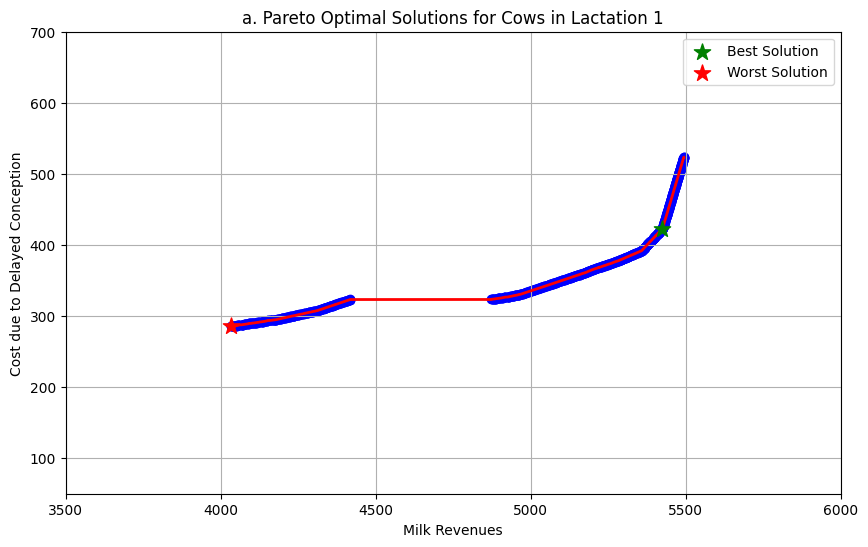

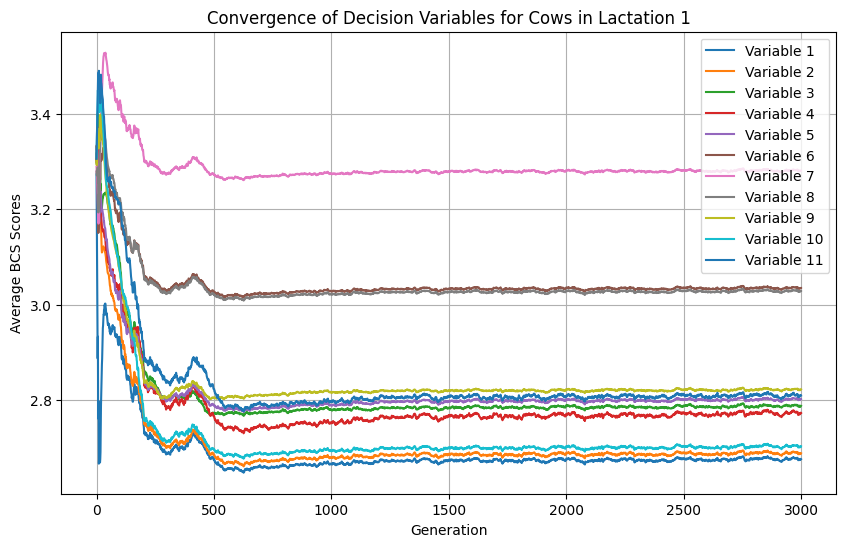

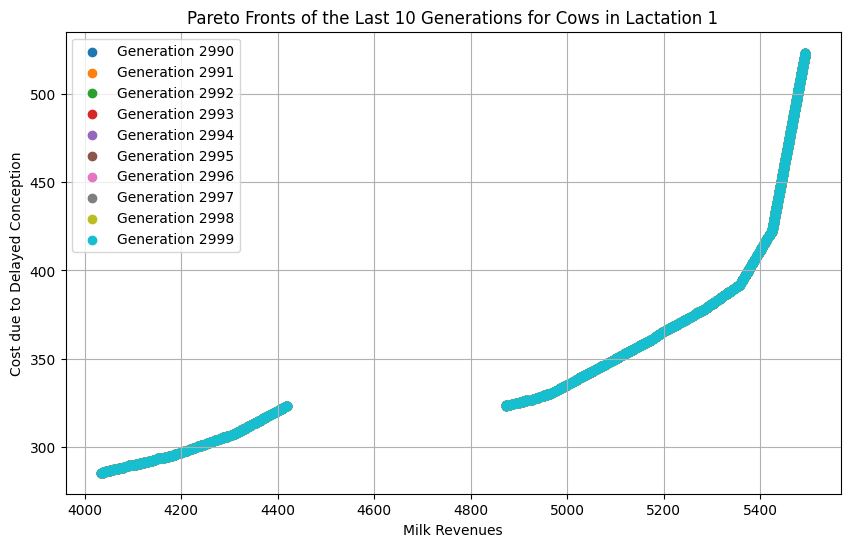

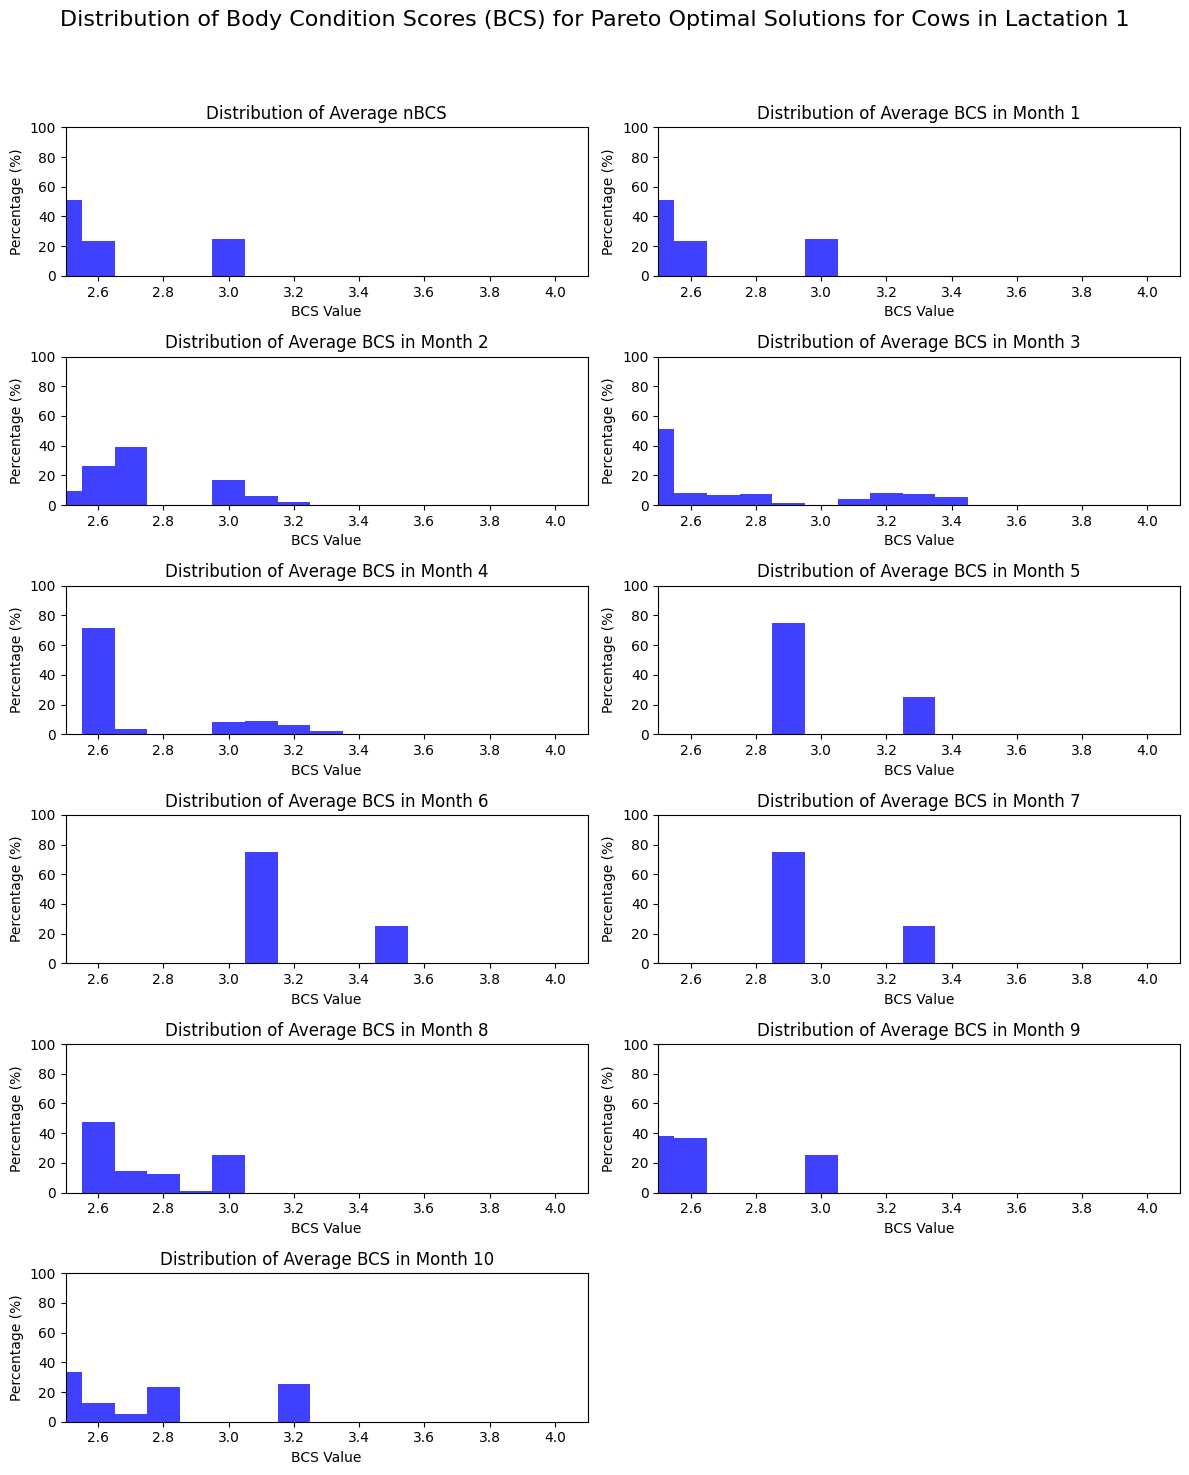

In [ ]:
# Lactation1
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.218:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.259:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.165:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.259:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.246:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.253:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.233:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.208:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.199:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (23167 - 137 * x[0] - 449 * x[1] + 853 * x[2]
                               - 2288 * x[3] - 1214 * x[4] - 930 * x[5]
                               + 2048 * x[6] - 1733 * x[7] + 431 * x[8]
                               + 311 * x[9] - 843 * x[10])

            conception_DIM = (155 - 77.0 * x[0] + 43.7 * x[1] + 14.3 * x[2]
                              - 30.0 * x[3] + 0.19 * x[4] + 14.6 * x[5]
                              - 25.7 * x[6] - 23.8 * x[7] + 59.5 * x[8]
                              + 48.1 * x[9] - 34.7 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])


# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star (plotted after the blue points)
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star (plotted after the blue points)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6000)
plt.ylim(50, 700)

plt.title('a. Pareto Optimal Solutions for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 1')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)  # Create subplots in a 5x2 grid

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage by multiplying by 100
    percentages = counts * np.diff(bins)[0] * 100

    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle(
    'Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 1',
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4144.60368047   232.89223463]
 [-5884.32235825   488.11602602]
 [-4770.92765849   271.82758427]
 ...
 [-5515.48720845   343.21598675]
 [-5356.53679525   314.9466961 ]
 [-5559.65538321   351.18617019]]

Final Decision Variables:
[[3.3073151  3.30796282 3.30778449 ... 3.53126081 3.3073609  3.52831546]
 [2.50006368 2.58497096 2.84491768 ... 2.75710042 2.88201889 2.66112494]
 [2.84914408 2.84944591 2.84934003 ... 3.07291653 2.84919727 3.06957711]
 ...
 [2.53449981 2.53469435 2.7946563  ... 2.75847098 2.53457384 2.75509132]
 [2.53457663 2.53460576 2.76354222 ... 2.75846605 2.53459944 2.75492931]
 [2.53455226 2.53466929 2.79452585 ... 2.75855726 2.53459032 2.75493812]]

Best Solution:
Objective Values: [-5870.97726293   459.48588447]
Decision Variables: [2.50540937 2.58499857 2.84495603 2.53699518 2.52925065 2.79915204
 2.54729228 2.5071609  2.75713235 2.72819782 2.50760061]

Worst Solution:
Objective Values: [-4144.60368047   232.89223463]
Decision Variables: [3.3

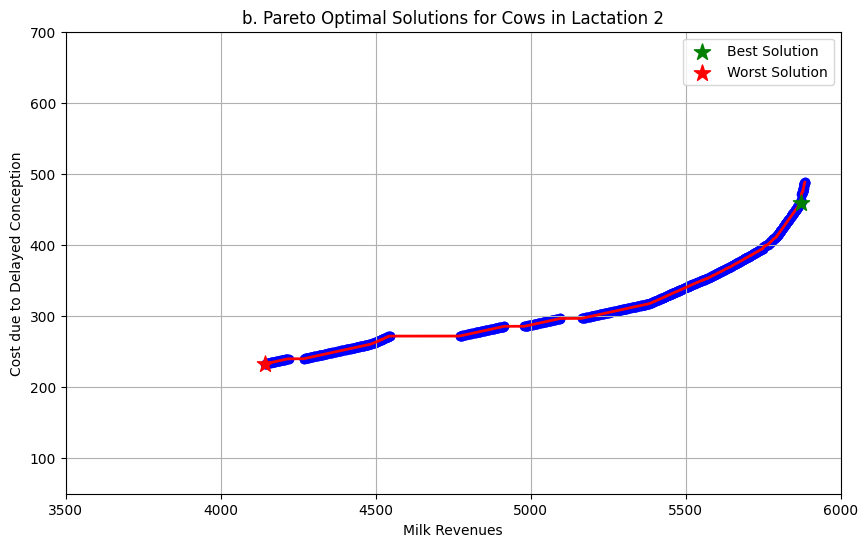

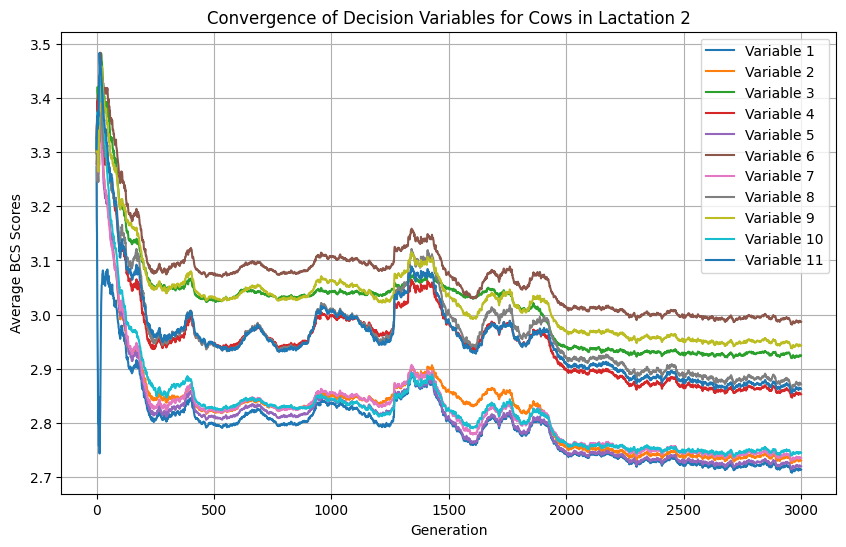

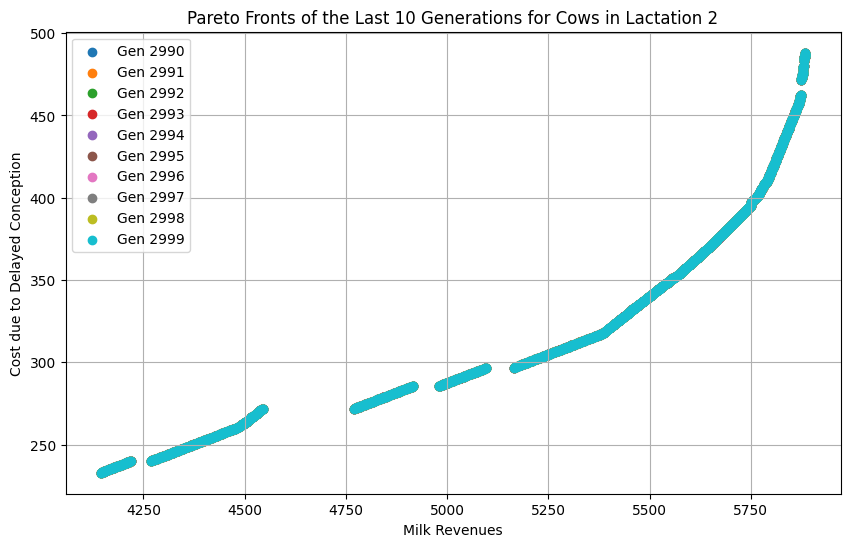

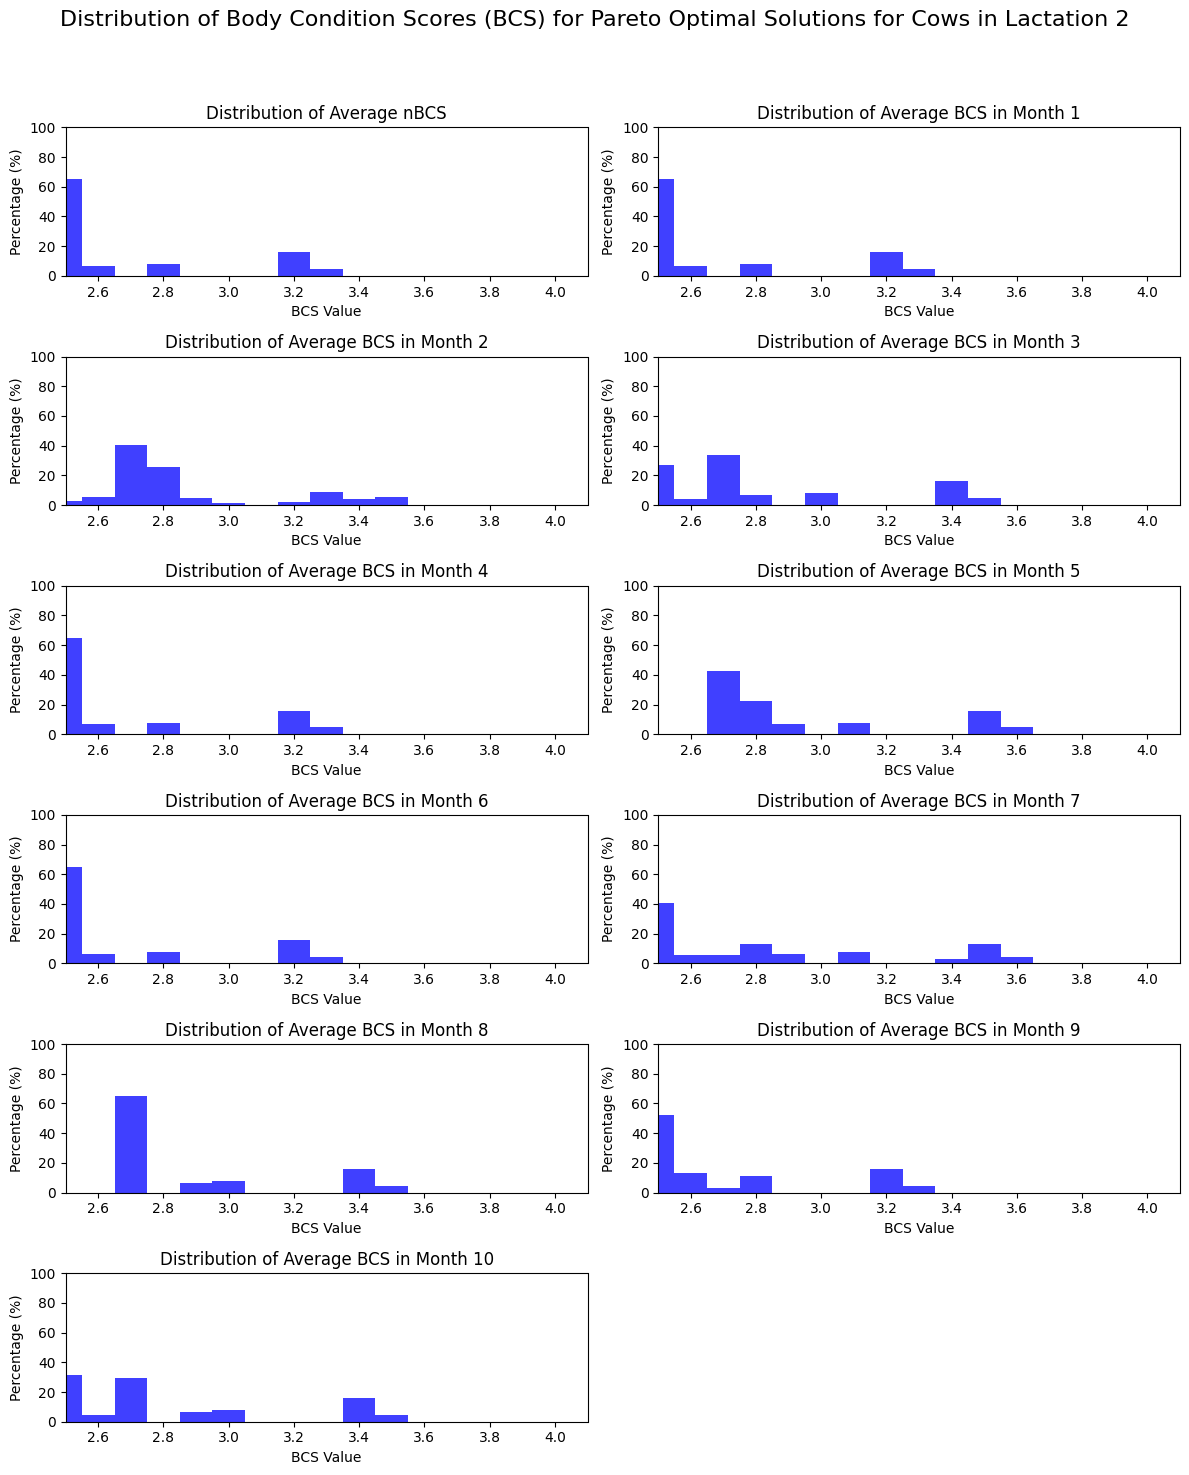

In [ ]:
# Lactation 2
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.260:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.308:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.183:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.270:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.252:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.250:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.224:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.221:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21344 - 563 * x[0] - 1135 * x[1] + 2097 * x[2]
                               - 1213 * x[3] - 1431 * x[4] + 1073 * x[5]
                               - 924 * x[6] - 1671 * x[7] + 447 * x[8]
                               + 1018 * x[9] - 822 * x[10])

            conception_DIM = (145 - 62.2 * x[0] + 11.5 * x[1] + 15.5 * x[2]
                              - 25.2 * x[3] + 25.9 * x[4] - 39.5 * x[5]
                              + 47.8 * x[6] - 25.3 * x[7] - 1.16 * x[8]
                              + 52.6 * x[9] - 15.4 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.40, 4.00, 5.13, 4.73, 4.23, 3.77, 3.27, 2.70, 2.20, 1.67]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('b. Pareto Optimal Solutions for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 2')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Gen {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 2', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4534.18139153   244.88986964]
 [-5880.31708785   661.69076948]
 [-4751.70621639   281.76702611]
 ...
 [-5384.06433697   376.81569056]
 [-5782.38053192   525.43485165]
 [-5526.25782091   405.43418316]]

Final Decision Variables:
[[3.0131284  3.01332513 3.01345199 ... 3.01315075 3.01688952 3.28088281]
 [2.50000001 2.56898818 2.87496729 ... 2.75724416 2.97036336 2.70636913]
 [3.01313444 3.01332465 3.01346343 ... 3.01316742 3.01704181 3.28071203]
 ...
 [2.5        2.50000172 2.500008   ... 2.50001051 2.50004123 2.76375324]
 [2.5        2.54651583 2.84908392 ... 2.50398781 2.76096698 2.50005111]
 [2.5        2.50010949 2.500073   ... 2.50002251 2.50635605 2.50007702]]

Best Solution:
Objective Values: [-5837.13402185   569.03784599]
Decision Variables: [2.5        2.56898377 2.87495264 2.5000008  2.50000082 2.50000163
 2.50000764 2.50002082 2.50473376 2.7639601  2.50007092]

Worst Solution:
Objective Values: [-4534.18139153   244.88986964]
Decision Variables: [3.0

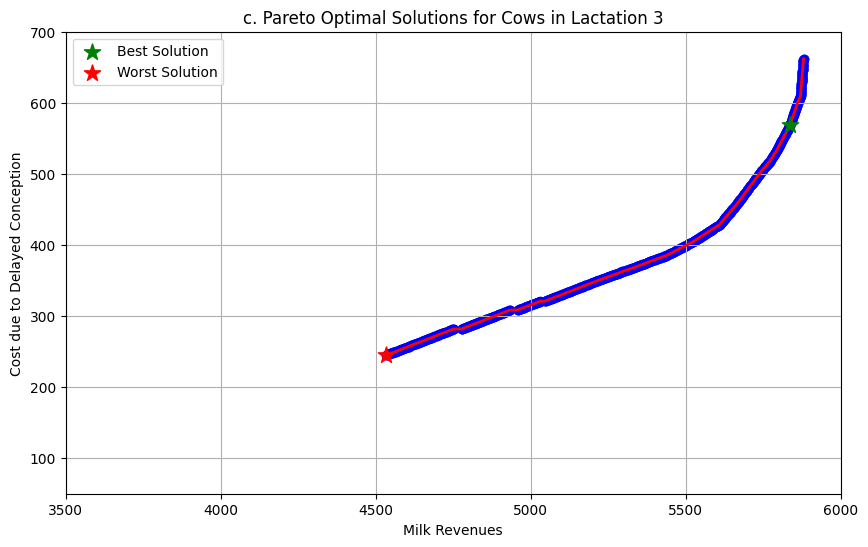

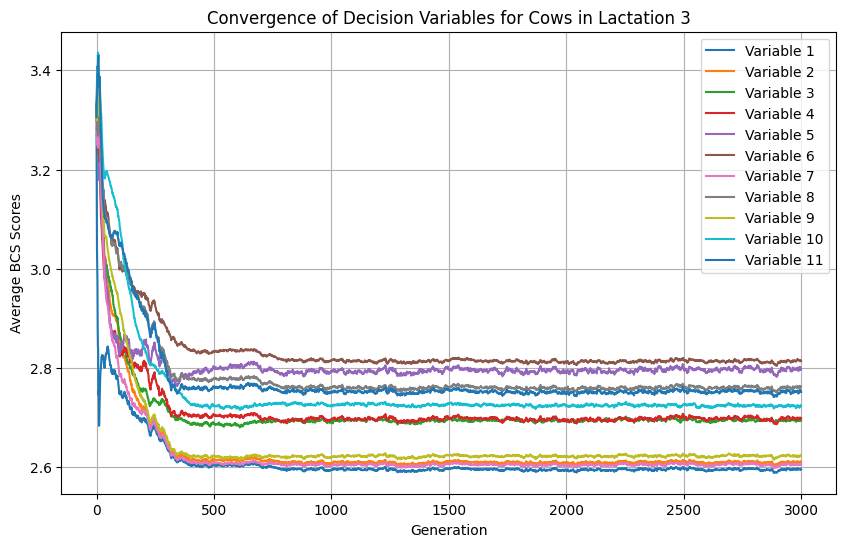

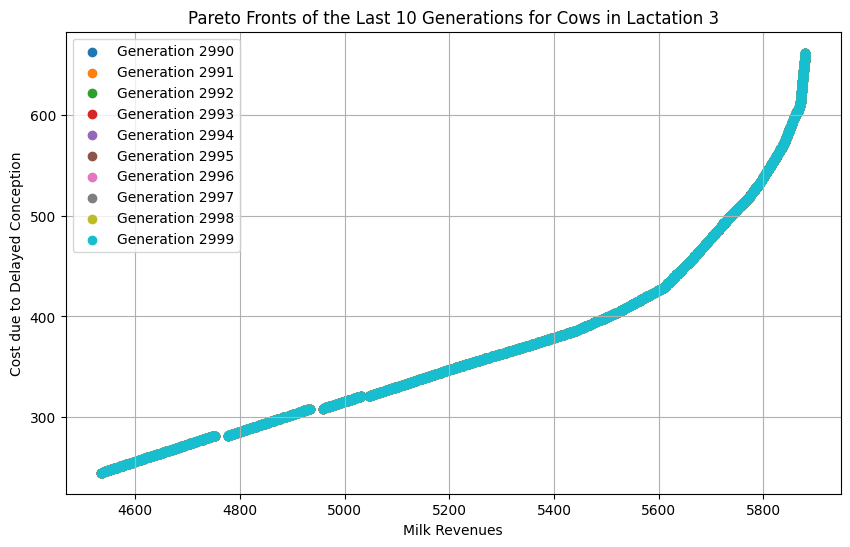

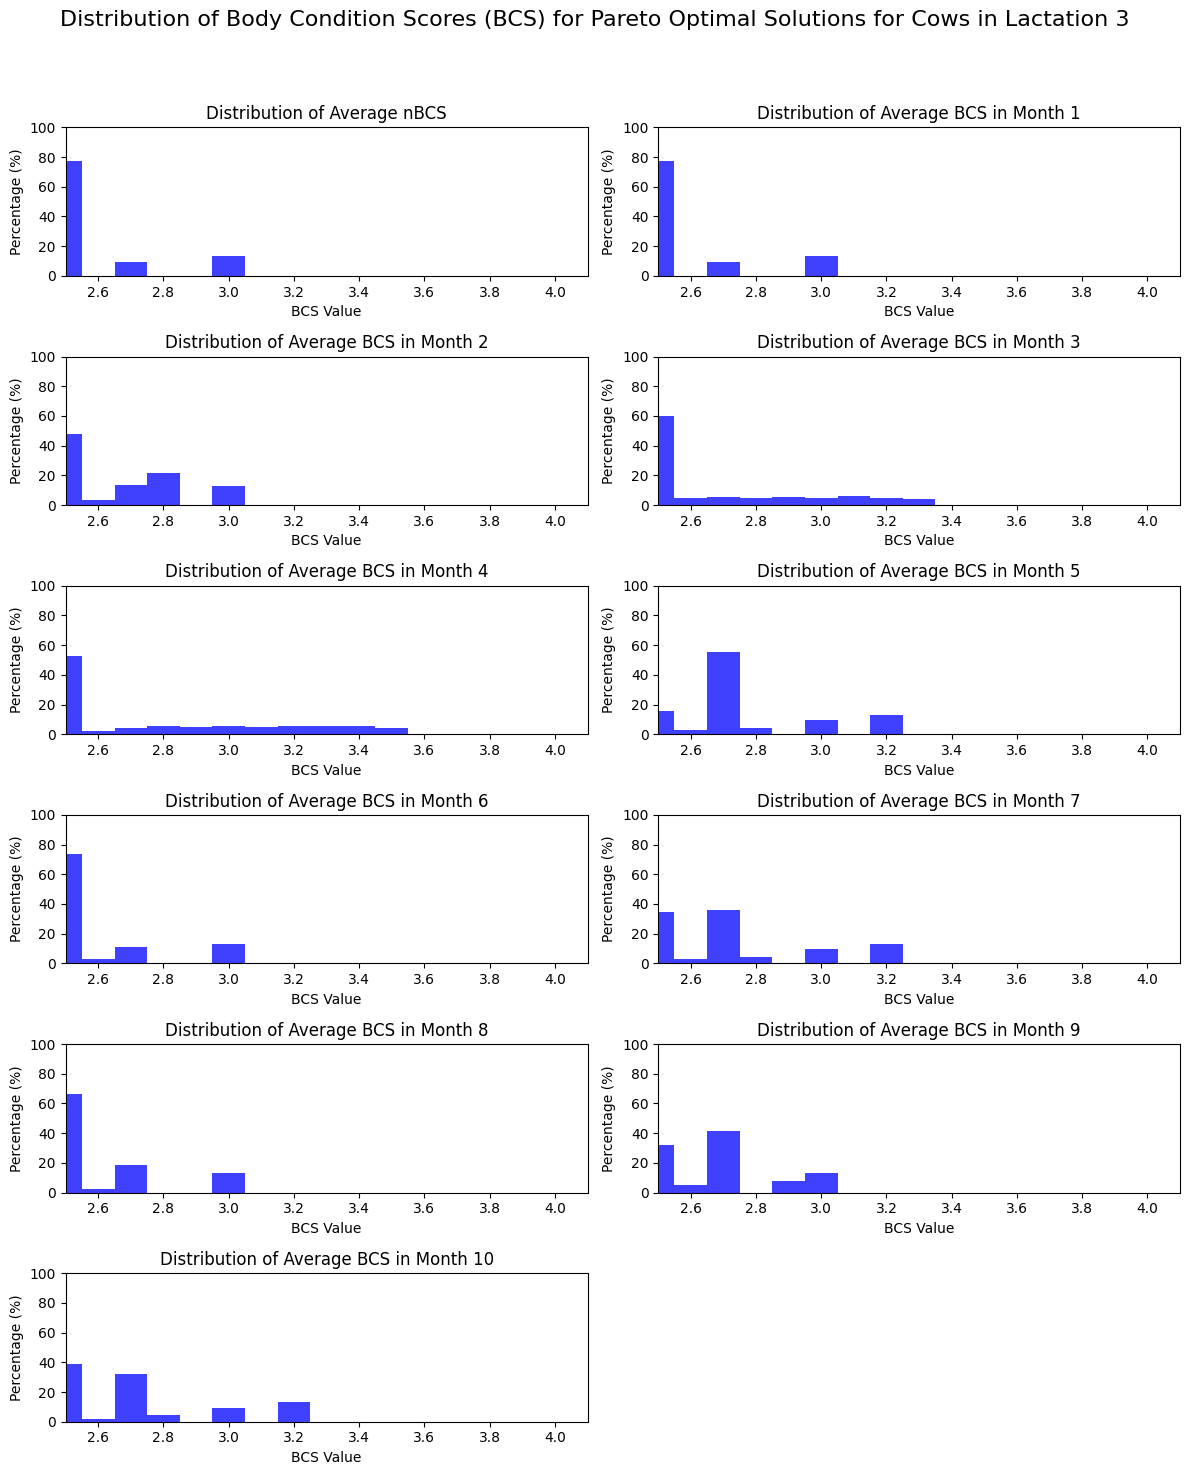

In [ ]:
# Lactation 3
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.306:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.375:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.246:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.293:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.260:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.277:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.260:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.264:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20295 - 519 * x[0] - 168 * x[1] + 867 * x[2] - 1074 * x[3]
                               -1063 * x[4] - 439 * x[5] + 94.7 * x[6] - 534 * x[7] + 282 * x[8]
                               + 829 * x[9] - 770 * x[10])

            conception_DIM = (182 - 72.4 * x[0] + 2.40 * x[1] + 39.6 * x[2] - 12.7 * x[3]
                               -13.6 * x[4] - 32.6 * x[5] + 47.4 * x[6] - 21.8 * x[7]
                               + 32.3 * x[8] + 18.2 * x[9] - 13.7 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.00, 4.13, 5.53, 5.10, 4.50, 3.90, 3.27, 2.60, 1.87, 1.10]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('c. Pareto Optimal Solutions for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 3')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 3', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4351.69210122    93.55714319]
 [-5979.98618708   645.12976824]
 [-4601.13310121   140.64786101]
 ...
 [-5887.00000246   493.2060885 ]
 [-5224.36110352   230.62095649]
 [-5460.75428191   296.12130275]]

Final Decision Variables:
[[3.12188876 3.1219696  3.39782568 ... 3.12189132 3.26858296 3.12326411]
 [2.50000004 3.37209399 3.0970939  ... 2.79600146 2.54543152 2.50003383]
 [3.1218886  3.12193044 3.39745652 ... 3.12208869 3.16117969 3.12232777]
 ...
 [2.5000077  2.80588568 3.08157996 ... 2.79161927 2.54603806 2.50003294]
 [2.50000007 2.50004473 2.77583482 ... 2.50382777 2.54530551 2.50001254]
 [2.50000015 2.50001566 2.77555496 ... 2.50194745 2.52529475 2.5000037 ]]

Best Solution:
Objective Values: [-5898.45839206   499.01358859]
Decision Variables: [2.50000006 2.82284538 3.0970829  2.71912491 2.50012762 2.77105251
 2.50007098 2.50000649 2.79600146 2.54543645 2.50000489]

Worst Solution:
Objective Values: [-4351.69210122    93.55714319]
Decision Variables: [3.1

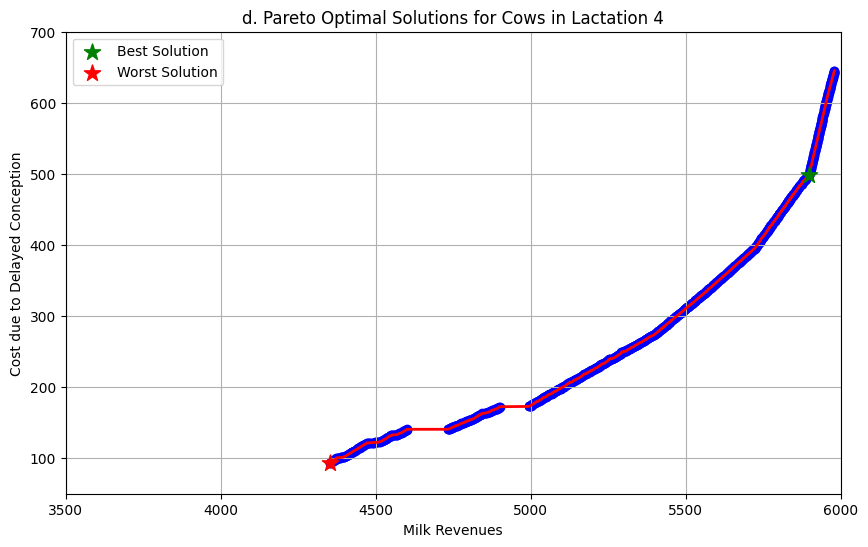

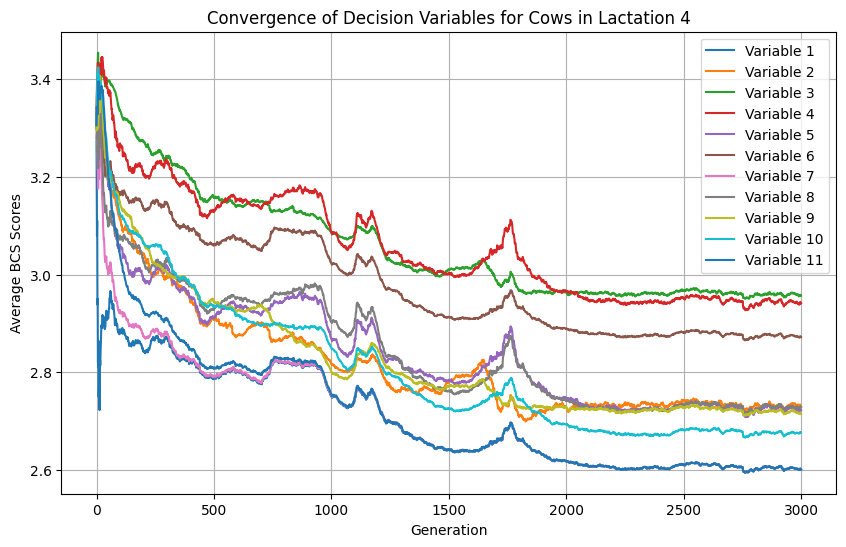

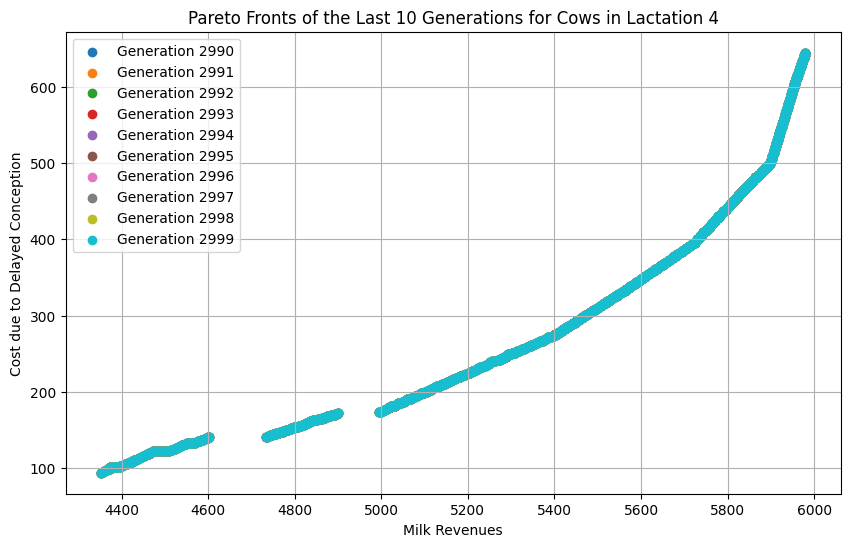

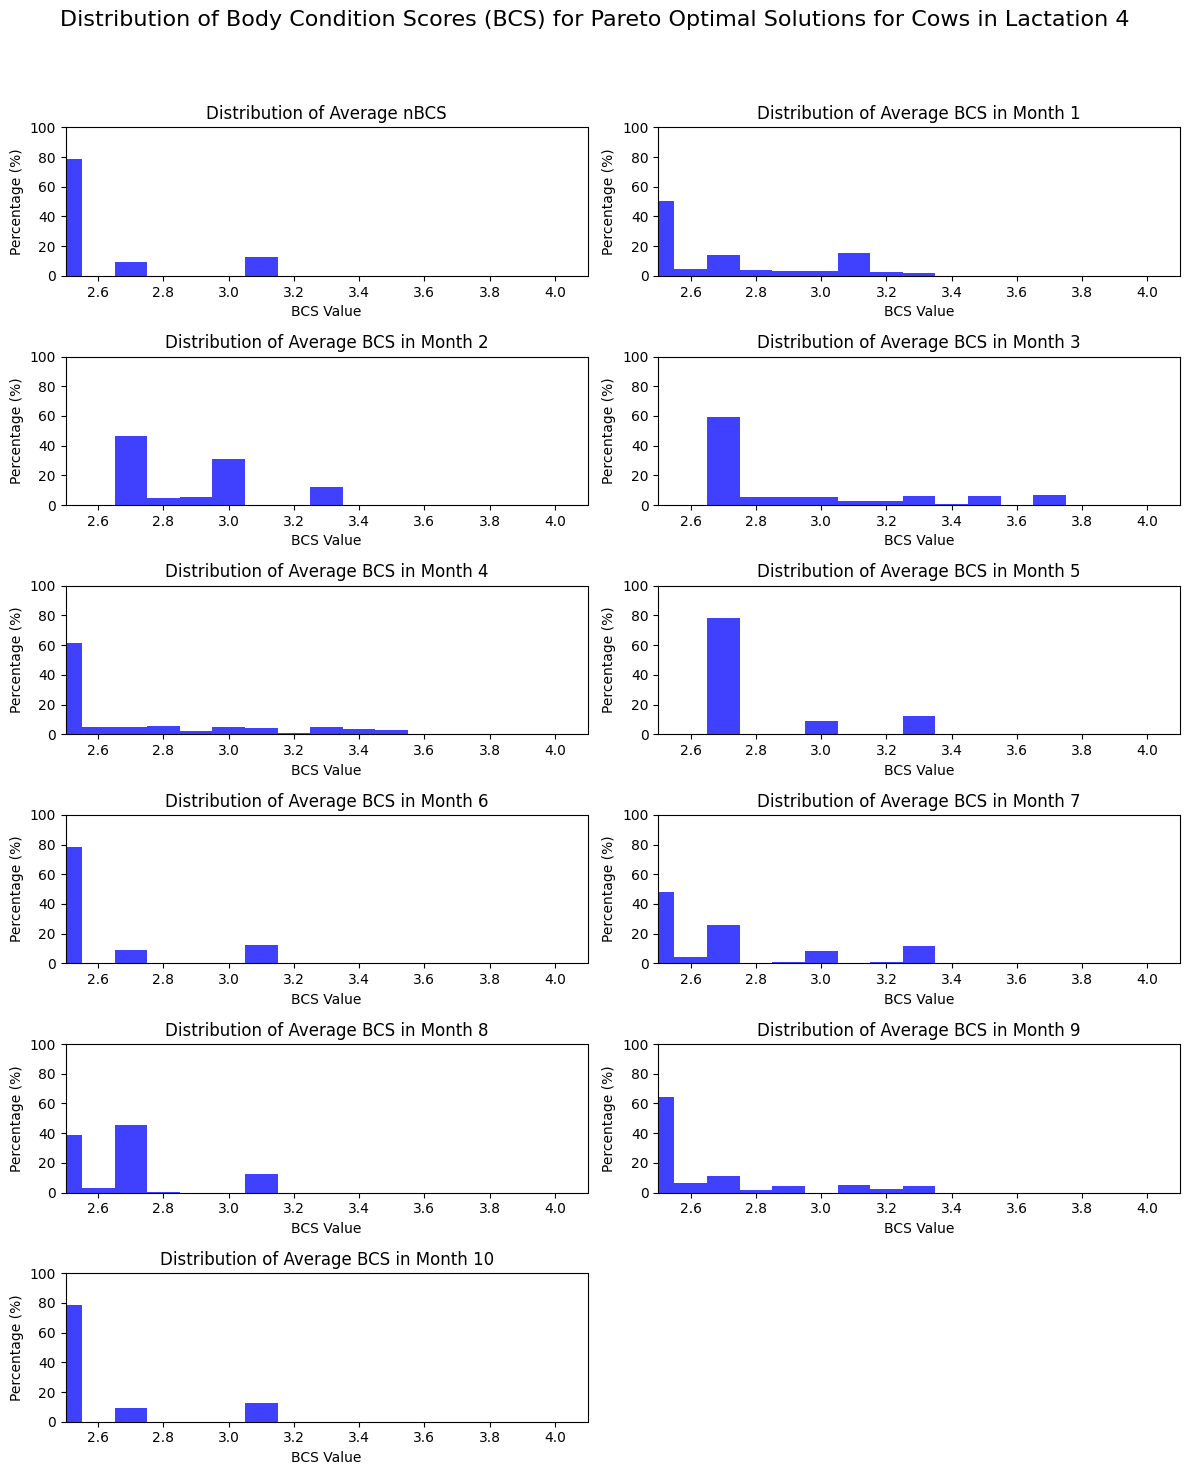

In [ ]:
# Lactation 4
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.276:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.378:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.219:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.271:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.259:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.296:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.251:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.233:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20094 - 732 * x[0] + 371 * x[1] + 986 * x[2] + 313 * x[3]
                               - 2613 * x[4] + 4.19 * x[5] - 558 * x[6] - 1553 * x[7]
                               + 1381 * x[8] - 64.8 * x[9] - 147 * x[10])

            conception_DIM = (194 - 93.7 * x[0] + 63.0 * x[1] + 3.13 * x[2] - 59.1 * x[3]
                               + 16.3 * x[4] - 37.2 * x[5] + 69.1 * x[6] - 42.0 * x[7]
                               + 43.1 * x[8] - 1.39 * x[9] + 6.15 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.73, 3.93, 5.37, 4.97, 4.37, 3.80, 3.17, 2.47, 1.77, 0.93]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('d. Pareto Optimal Solutions for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 4')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 4', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5792.62202892   566.78941832]
 [-4108.91632113   275.90323185]
 [-5775.2381944    560.287546  ]
 ...
 [-5300.72225306   392.56551355]
 [-5763.01849792   521.35335186]
 [-5723.52374045   504.87852095]]

Final Decision Variables:
[[2.50000333 2.87559771 3.1413645  ... 3.19186677 3.42329592 3.19806094]
 [3.09790358 3.09804593 3.09890682 ... 3.18231208 3.14515199 3.37097505]
 [2.50000382 2.87560409 3.14136452 ... 3.19186838 3.42329103 3.28569558]
 ...
 [2.5000002  2.50000287 2.76541286 ... 2.5000176  2.6878536  2.91170285]
 [2.50000298 2.74197893 3.00794548 ... 2.75137639 2.9832033  2.81641435]
 [2.50000008 2.74199434 3.0079702  ... 2.75158104 2.98327347 3.01524369]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5774.69755678   526.27979804]
Decision Variables:
[2.5        2.74197929 3.00796955 2.68700679 2.5000088  2.77395842
 2.76601208 2.50001286 2.75160207 2.9821211  2.75613743]

Worst Solution:
Objective Values (Weig

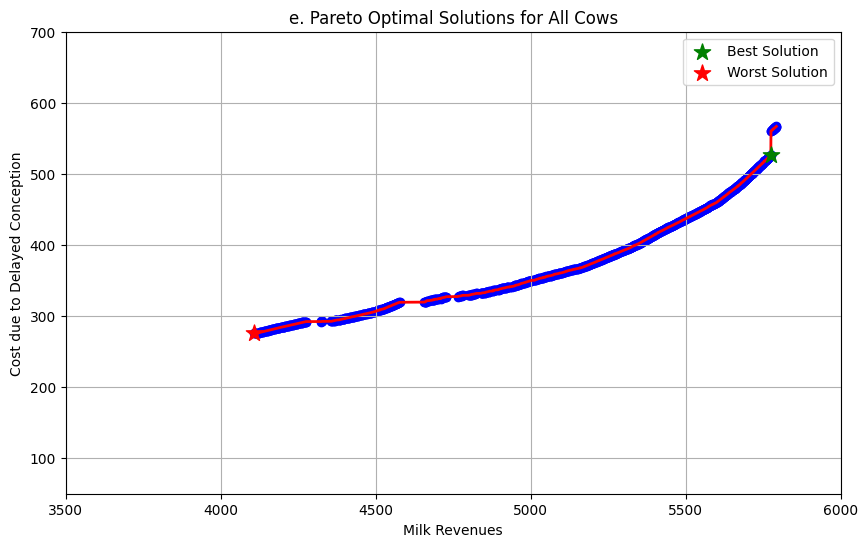

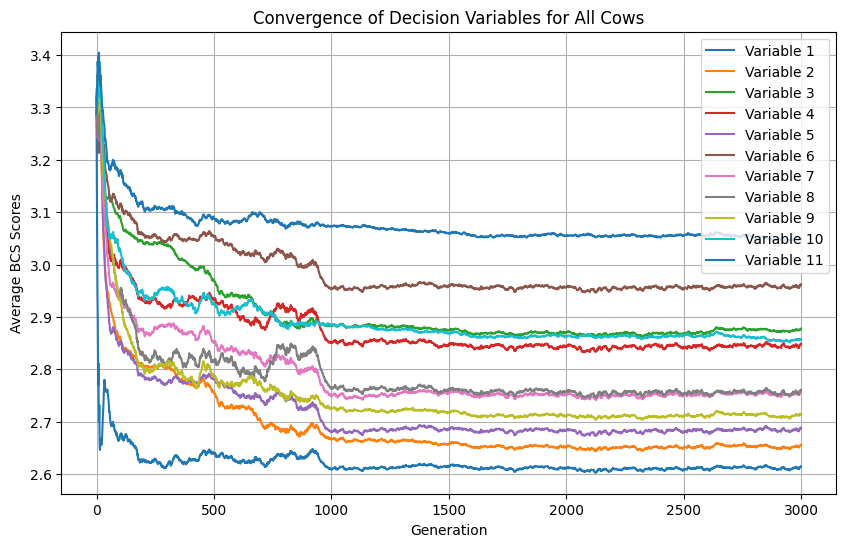

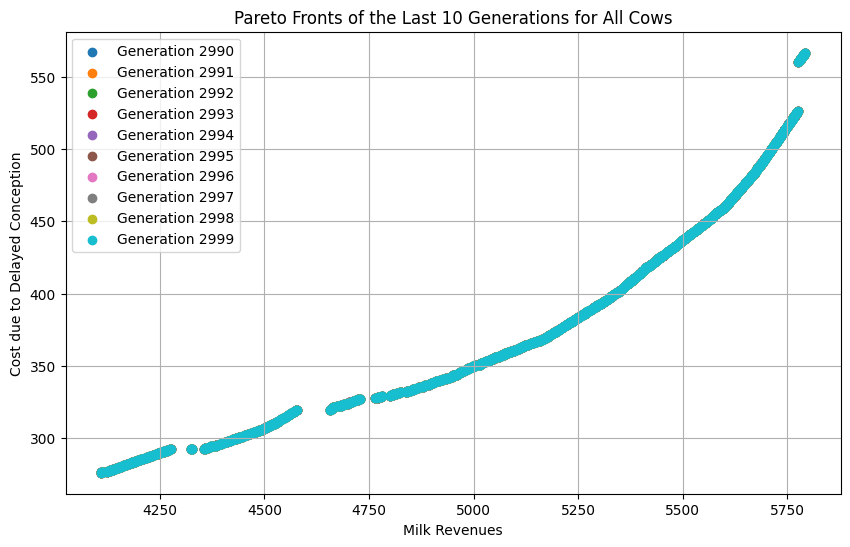

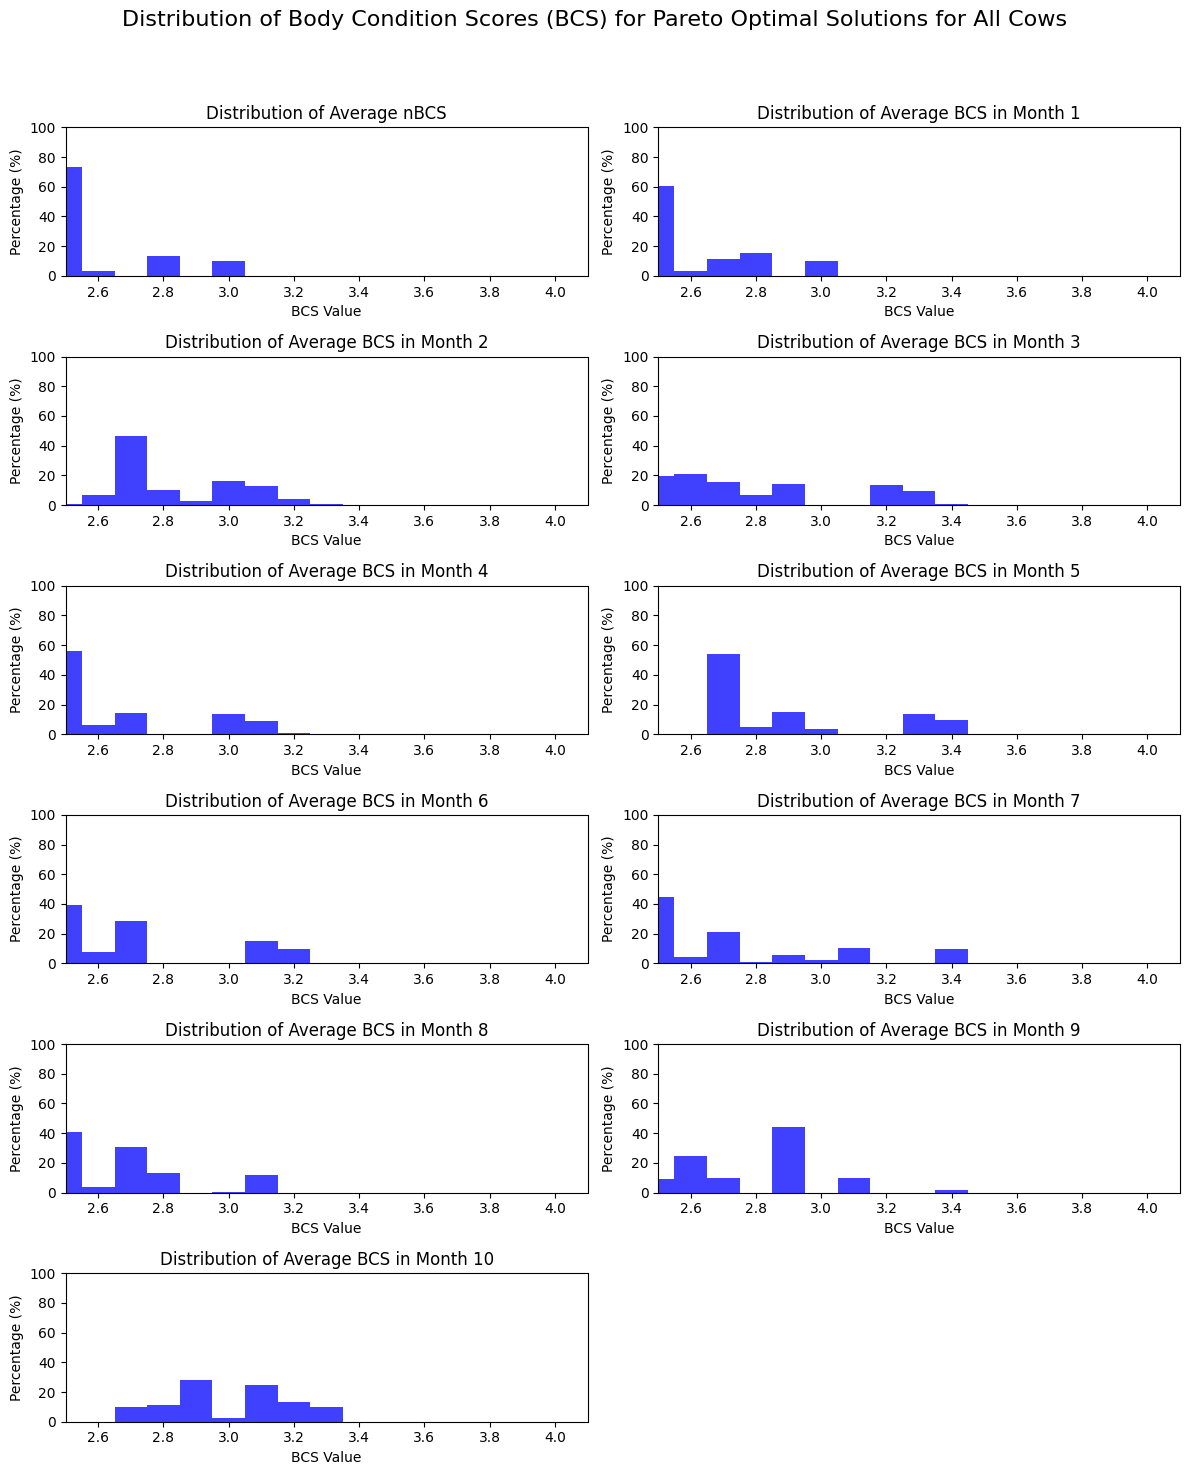

In [2]:
#All Cows
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            # (Though you've put these in a for-loop over i in range(9),
            #  notice you are not using 'i' here, so the same set of checks
            #  effectively runs 9 times. You can keep or remove that loop
            #  depending on your intent. Below is kept as-is.)
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.266:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.321:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.201:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.254:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.266:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.252:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.232:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.226:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            # Penalize any violation where x[0] > x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            # Your objective calculations
            milk_production = (20514 - 2192 * x[0] - 383 * x[1]
                               + 1760 * x[2] - 1204 * x[3]
                               - 1919 * x[4] + 283 * x[5]
                               + 740 * x[6] - 1499 * x[7]
                               + 819 * x[8] + 1080 * x[9]
                               - 496 * x[10])

            conception_DIM = (182 - 39.7 * x[0] + 17.5 * x[1]
                              + 15.7 * x[2] - 26.6 * x[3]
                              + 12.2 * x[4] - 31.8 * x[5]
                              + 24.4 * x[6] - 24.1 * x[7]
                              + 23.3 * x[8] + 27.9 * x[9]
                              - 20.5 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6000)
plt.ylim(50, 700)

plt.title('e. Pareto Optimal Solutions for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for All Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage
    percentages = counts * np.diff(bins)[0] * 100

    # Plot the histogram using percentage on y-axis
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for All Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5847.46903625   494.45487096]
 [-4099.53797051   207.0872994 ]
 [-4816.23073933   278.90039454]
 ...
 [-4567.01611717   258.33742748]
 [-4523.32329604   249.90715273]
 [-4220.02177545   219.37224964]]

Final Decision Variables:
[[2.5        2.58005591 2.86201537 ... 2.75692209 2.73518056 2.50018243]
 [3.34426317 3.34436457 3.34432214 ... 3.39416886 3.34499514 3.57987515]
 [2.70538473 2.70541497 2.71387418 ... 2.72200792 2.70539986 2.93937327]
 ...
 [3.12621269 3.12641551 3.23112919 ... 3.12625887 3.12626962 3.31418773]
 [3.12620916 3.12641958 3.18425622 ... 3.12622259 3.1263004  3.36010148]
 [3.34425854 3.34435857 3.35143727 ... 3.35931243 3.3450183  3.57984481]]

Best Solution:
Objective Values: [-5847.46903625   494.45487096]
Decision Variables: [2.5        2.58005591 2.86201537 2.5166486  2.50000001 2.75799042
 2.50000047 2.5000001  2.75692209 2.73518056 2.50018243]

Worst Solution:
Objective Values: [-4099.53797051   207.0872994 ]
Decision Variables: [3.3

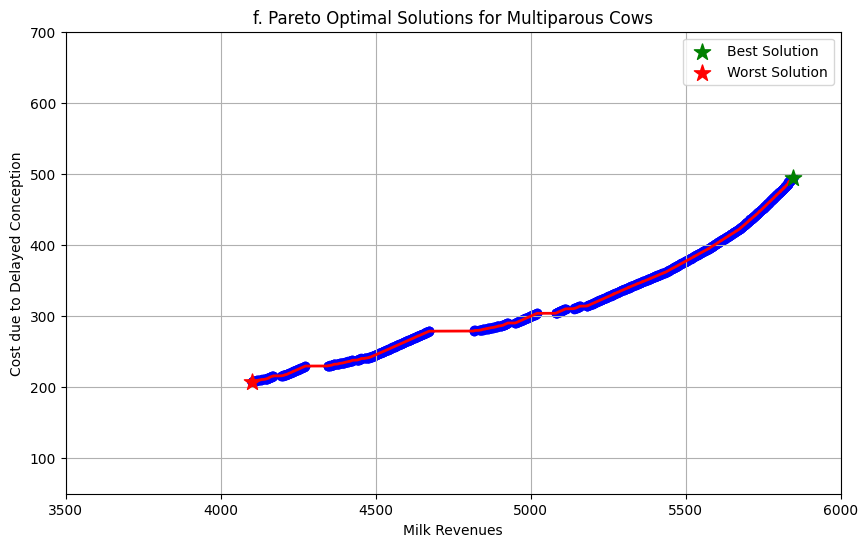

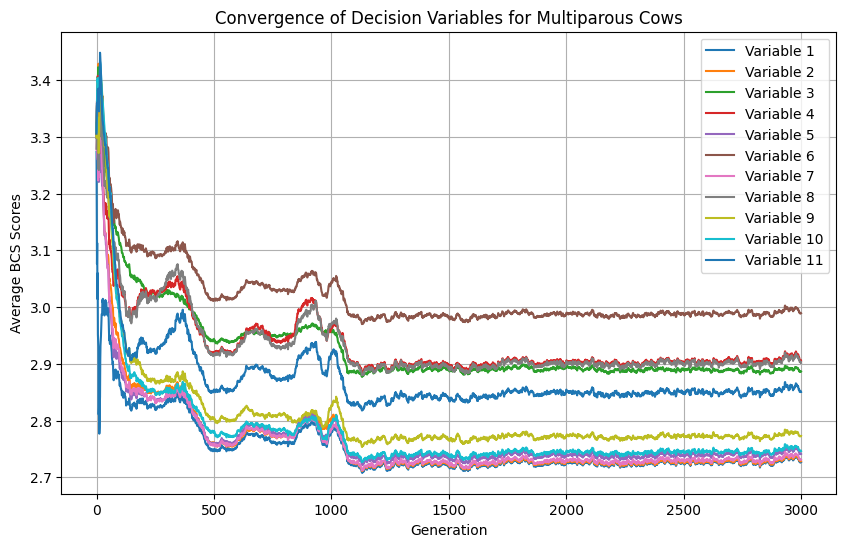

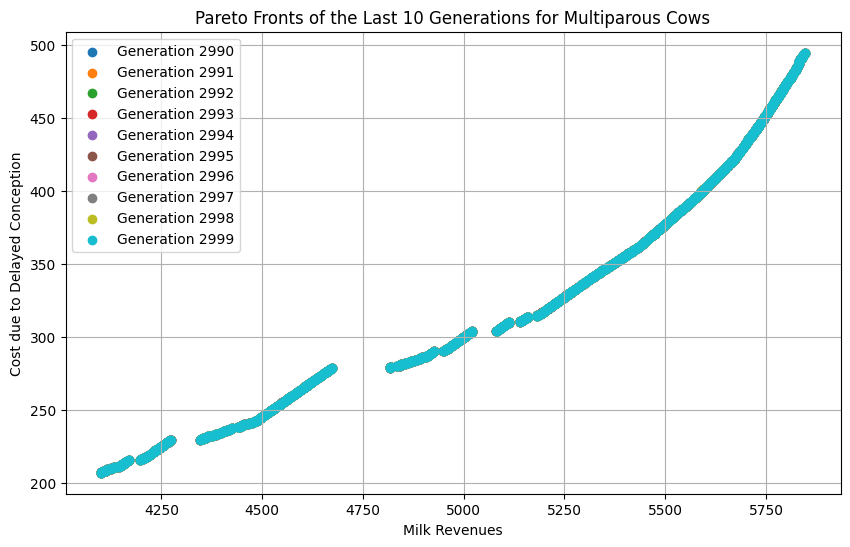

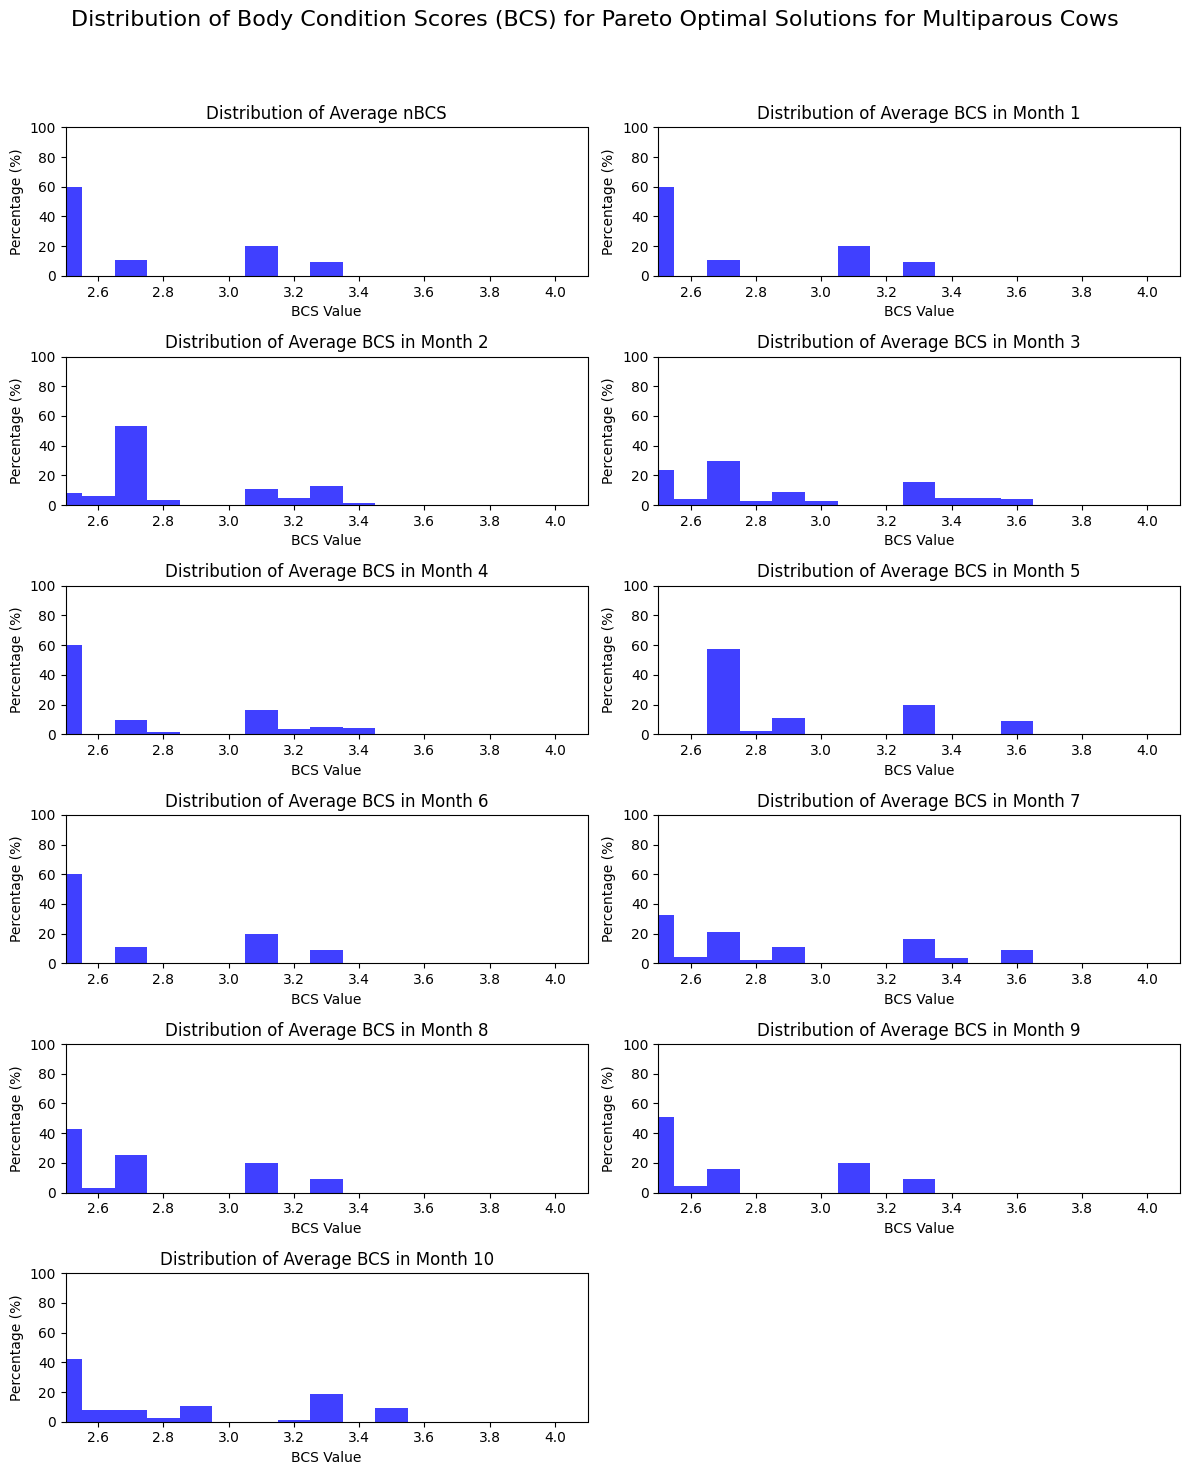

In [ ]:
# Multiparous
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.282:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.346:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.217:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.279:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.258:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.237:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.235:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20662 - 665 * x[0] - 573 * x[1] + 1651 * x[2] - 1116 * x[3]
                               - 1470 * x[4] + 103 * x[5] - 159 * x[6] - 1355 * x[7]
                               + 607 * x[8] + 908 * x[9] - 720 * x[10])

            conception_DIM = (164 - 71.4 * x[0] + 15.8 * x[1] + 23.9 * x[2] - 25.1 * x[3]
                               + 7.78 * x[4] - 40.5 * x[5] + 55.3 * x[6] - 26.3 * x[7]
                               + 18.5 * x[8] + 31.0 * x[9] - 10.6 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.04, 4.02, 5.34, 4.93, 4.37, 3.82, 3.23, 2.59, 1.94, 1.23]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worse_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worse_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6000)
plt.ylim(50, 700)
plt.title('f. Pareto Optimal Solutions for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Multiparous Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Multiparous Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()